# Dataset 03: Human Kidney Cell Atlas
**Source:** https://cellxgene.cziscience.com/collections/dc3a5256-5c39-4a21-ac0c-4ede3e7b2323  
**Donors:** 19 healthy individuals  
**Cells:** 8,746 (500 per donor, capped)  
**Cell types:** 9  

## Preprocessing Convention
| Parameter | Value |
|---|---|
| HVGs | 1000 (batch_key = donor_id) |
| PCA computed | 50 |
| PCA / Harmony / scVI dims kept | 15 |
| Max cells per donor | 500 |

## Notes
- X in raw h5ad is SCT-normalized; raw counts recovered from `.raw` and re-normalized with normalize_total + log1p for consistency
- `batch` = `library_preparation_batch` (19 batches, one per donor)
- `unknown` cell type excluded during filtering (failed min_donors threshold)

In [2]:
import sys
from pathlib import Path
import os
import scanpy as sc
import numpy as np

REPO_ROOT = Path("~/scRNA-cross-donor-generalization").expanduser()
os.chdir(REPO_ROOT)
sys.path.append(str(REPO_ROOT / "src"))

In [3]:
from pathlib import Path
import scanpy as sc

adata_path = Path("data/kidney/kidney.h5ad")
adata = sc.read_h5ad(adata_path)

print(adata)

print("\nobs columns:")
print(adata.obs.columns.tolist())

print("\nvar columns:")
print(adata.var.columns.tolist())

print("\nobsm keys:")
print(list(adata.obsm.keys()))

for col in [
    "donor_id",
    "cell_type",
    "cell_type_original",
    "author_cell_type",
    "assay",
    "suspension_type",
    "tissue",
    "tissue_general",
    "disease",
    "sample_id",
    "batch",
]:
    if col in adata.obs.columns:
        print(f"\n{col}:")
        print(adata.obs[col].value_counts(dropna=False).head(20))

AnnData object with n_obs × n_vars = 27675 × 26791
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'sampletype', 'CMVstatus', 'percent.mt', 'Group', 'Female', 'Male', 'sampleType', 'log10GenesPerUMI', 'nCount_SCT', 'nFeature_SCT', 'SCT_snn_res.0.8', 'seurat_clusters', 'S.Score', 'G2M.Score', 'Phase', 'percent.ribo', 'study_pi', 'sample_id', 'donor_id', 'protocol_url', 'institute', 'library_id', 'library_id_repository', 'manner_of_death', 'sample_source', 'sex_ontology_term_id', 'sample_collection_method', 'tissue_type', 'sampled_site_condition', 'tissue_ontology_term_id', 'tissue_free_text', 'sample_preservation_method', 'suspension_type', 'cell_enrichment', 'assay_ontology_term_id', 'sequenced_fragment', 'sequencing_platform', 'is_primary_data', 'reference_genome', 'alignment_software', 'intron_inclusion', 'disease_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'development_stage_ontology_term_id', 'library_preparation_batch', 'library_sequencing_run', 'gene_annot

In [4]:
for col in [
    "donor_id",
    "sample_id",
    "library_id",
    "library_preparation_batch",
    "library_sequencing_run",
    "sample_source",
    "cell_enrichment",
    "sampled_site_condition",
    "sex",
    "disease",
    "tissue",
]:
    if col in adata.obs:
        print(f"\n{col}")
        print(adata.obs[col].value_counts(dropna=False))


donor_id
donor_id
HKB15    4738
HKB17    3739
HKB18    3280
HKB16    2366
HKB33    1894
HKB32    1811
HKB34    1264
HKB24    1182
HKB23    1102
HKB14    1080
HKB27    1041
HKB13     938
HKB28     712
HKB31     606
HKB10     584
HKB26     553
HKB21     344
HKB11     315
HKB19     126
Name: count, dtype: int64

sample_id
sample_id
Total2     4738
Total4     3739
Total5     3280
Total3     2366
Total8     1894
Total7     1811
Total9     1264
CD45_7     1182
CD45_6     1102
Total1     1080
CD45_9     1041
CD45_3      938
CD45_10     712
Total6      606
CD45_1      584
CD45_8      553
CD45_5      344
CD45_2      315
CD45_4      126
Name: count, dtype: int64

library_id
library_id
Total2     4738
Total4     3739
Total5     3280
Total3     2366
Total8     1894
Total7     1811
Total9     1264
CD45_7     1182
CD45_6     1102
Total1     1080
CD45_9     1041
CD45_3      938
CD45_10     712
Total6      606
CD45_1      584
CD45_8      553
CD45_5      344
CD45_2      315
CD45_4      126
Name: count

In [5]:
import pandas as pd

cols = ["donor_id", "sample_id", "library_id", "library_preparation_batch", "cell_enrichment"]
cols = [c for c in cols if c in adata.obs.columns]

donor_meta = (
    adata.obs[cols]
    .drop_duplicates()
    .sort_values("donor_id")
)

print(donor_meta.to_string(index=False))

donor_id sample_id library_id library_preparation_batch cell_enrichment
   HKB10    CD45_1     CD45_1                   batch01     CL:0000738+
   HKB11    CD45_2     CD45_2                   batch02     CL:0000738+
   HKB13    CD45_3     CD45_3                   batch03     CL:0000738+
   HKB14    Total1     Total1                   batch11              na
   HKB15    Total2     Total2                   batch12              na
   HKB16    Total3     Total3                   batch13              na
   HKB17    Total4     Total4                   batch14              na
   HKB18    Total5     Total5                   batch15              na
   HKB19    CD45_4     CD45_4                   batch04     CL:0000738+
   HKB21    CD45_5     CD45_5                   batch05     CL:0000738+
   HKB23    CD45_6     CD45_6                   batch06     CL:0000738+
   HKB24    CD45_7     CD45_7                   batch07     CL:0000738+
   HKB26    CD45_8     CD45_8                   batch08     CL:0

In [6]:
print("CELLxGENE cell_type:")
print(adata.obs["cell_type"].value_counts())

print("\nauthor_cell_type:")
print(adata.obs["author_cell_type"].value_counts())

CELLxGENE cell_type:
cell_type
epithelial cell of proximal tubule                                    20983
kidney loop of Henle cortical thick ascending limb epithelial cell     1156
kidney loop of Henle descending limb epithelial cell                   1011
mononuclear phagocyte                                                   999
T cell                                                                  938
kidney capillary endothelial cell                                       572
natural killer cell                                                     466
renal principal cell                                                    455
renal alpha-intercalated cell                                           304
renal beta-intercalated cell                                            130
mesangial cell                                                          130
kidney connecting tubule epithelial cell                                122
kidney distal convoluted tubule epithelial cell          

In [7]:
mapping = (
    adata.obs[["author_cell_type", "cell_type"]]
    .drop_duplicates()
    .sort_values(["cell_type", "author_cell_type"])
)

print(mapping.to_string(index=False))

author_cell_type                                                          cell_type
               B                                                             B cell
         CCDlike                      kidney cortex collecting duct epithelial cell
             CNT                           kidney connecting tubule epithelial cell
            CTAL kidney loop of Henle cortical thick ascending limb epithelial cell
             DCT                    kidney distal convoluted tubule epithelial cell
     Endothelial                                  kidney capillary endothelial cell
             ICA                                      renal alpha-intercalated cell
             ICB                                       renal beta-intercalated cell
         LOHlike               kidney loop of Henle descending limb epithelial cell
       Mesangial                                                     mesangial cell
             MNP                                              mononuclear ph

In [8]:
from scrna_benchmark.filtering import summarize_celltype_support

support_df = summarize_celltype_support(adata, celltype_col="cell_type", donor_col="donor_id",
                                        min_cells=200, min_donors=5)
print(support_df.to_string(index=False))

adata_filt = adata[adata.obs["cell_type"].isin(
    support_df[support_df["keep"]]["cell_type"].tolist()
)].copy()

                                                         cell_type  n_cells  n_donors  keep_by_cell_count  keep_by_donor_coverage  keep
                                epithelial cell of proximal tubule    20983        19                True                    True  True
kidney loop of Henle cortical thick ascending limb epithelial cell     1156        18                True                    True  True
              kidney loop of Henle descending limb epithelial cell     1011        19                True                    True  True
                                             mononuclear phagocyte      999        16                True                    True  True
                                                            T cell      938        12                True                    True  True
                                 kidney capillary endothelial cell      572        19                True                    True  True
                                               n

In [9]:
for col in ["cell_enrichment", "sample_source", "sampletype", "sampleType", "sampled_site_condition"]:
    if col in adata.obs:
        print(f"\n{col}")
        print(adata.obs[col].value_counts(dropna=False))


cell_enrichment
cell_enrichment
na             20778
CL:0000738+     6897
Name: count, dtype: int64

sample_source
sample_source
living organ donor    27675
Name: count, dtype: int64

sampletype
sampletype
NaN    20778
LD      6897
Name: count, dtype: int64

sampleType
sampleType
LD    27675
Name: count, dtype: int64

sampled_site_condition
sampled_site_condition
healthy    27675
Name: count, dtype: int64


In [10]:
pd.crosstab(adata.obs["donor_id"], adata.obs["cell_enrichment"])

cell_enrichment,CL:0000738+,na
donor_id,,
HKB10,584,0
HKB11,315,0
HKB13,938,0
HKB14,0,1080
HKB15,0,4738
HKB16,0,2366
HKB17,0,3739
HKB18,0,3280
HKB19,126,0


In [11]:
pd.crosstab(adata.obs["cell_type"], adata.obs["cell_enrichment"])

cell_enrichment,CL:0000738+,na
cell_type,,
B cell,58,10
kidney cortex collecting duct epithelial cell,4,41
kidney connecting tubule epithelial cell,76,46
kidney loop of Henle cortical thick ascending limb epithelial cell,642,514
kidney distal convoluted tubule epithelial cell,51,58
kidney capillary endothelial cell,252,320
renal alpha-intercalated cell,106,198
renal beta-intercalated cell,49,81
kidney loop of Henle descending limb epithelial cell,82,929


In [12]:
import numpy as np
from scipy import sparse

X = adata.X
vals = X.data if sparse.issparse(X) else X.ravel()
vals_sample = vals[:100000]

print("min:", vals_sample.min())
print("max:", vals_sample.max())
print("mean:", vals_sample.mean())
print("integer-like:", np.allclose(vals_sample, np.round(vals_sample)))

min: 0.0
max: 4553.716
mean: 4.6264234
integer-like: False


In [13]:
# Check what's in .raw
print("raw X shape:", adata_filt.raw.X.shape)

raw_vals = adata_filt.raw.X.data[:100000] if sparse.issparse(adata_filt.raw.X) else adata_filt.raw.X.ravel()[:100000]
print("raw min:", raw_vals.min())
print("raw max:", raw_vals.max())
print("raw mean:", raw_vals.mean())
print("integer-like:", np.allclose(raw_vals, np.round(raw_vals)))

raw X shape: (26884, 26791)
raw min: 1.0
raw max: 3999.0
raw mean: 3.8739
integer-like: True


In [14]:
# Confirm raw counts are not normalized
total_per_cell = np.array(adata_filt.raw.X.sum(axis=1)).flatten()
print(f"Total counts per cell — min: {total_per_cell.min():.1f}, max: {total_per_cell.max():.1f}, mean: {total_per_cell.mean():.1f}")
print(f"Integer-like: {np.allclose(adata_filt.raw.X.data[:10000], np.round(adata_filt.raw.X.data[:10000]))}")
# If integer and large counts → raw, safe to normalize

Total counts per cell — min: 651.0, max: 200219.0, mean: 9166.3
Integer-like: True


In [15]:
# Use raw counts as our starting point
adata_filt.layers["counts"] = adata_filt.raw.X.copy()

# Normalize and log1p
sc.pp.normalize_total(adata_filt, layer="counts", target_sum=1e4)
sc.pp.log1p(adata_filt, layer="counts")

# Set X to the normalized counts
adata_filt.X = adata_filt.layers["counts"].copy()

In [16]:
# Downsample to 500 cells per donor
np.random.seed(42)
cells_to_keep = []

for donor, idx in adata_filt.obs.groupby("donor_id", observed=True).groups.items():
    idx = np.array(list(idx))
    cells_to_keep.extend(np.random.choice(idx, min(len(idx), 500), replace=False))

adata_filt = adata_filt[cells_to_keep].copy()
print(f"After downsampling: {adata_filt.n_obs:,} cells, {adata_filt.obs['donor_id'].nunique()} donors")
print(adata_filt.obs["donor_id"].value_counts())

After downsampling: 8,746 cells, 19 donors
donor_id
HKB10    500
HKB13    500
HKB14    500
HKB31    500
HKB15    500
HKB16    500
HKB17    500
HKB18    500
HKB23    500
HKB26    500
HKB24    500
HKB33    500
HKB32    500
HKB27    500
HKB28    500
HKB34    500
HKB21    332
HKB11    302
HKB19    112
Name: count, dtype: int64


In [17]:
# Standardize metadata columns
adata_filt.obs["batch"] = adata_filt.obs["library_preparation_batch"].astype(str)

print(adata_filt.obs[["donor_id", "cell_type", "batch", "sample_id"]].head())
print("\nbatch values:", adata_filt.obs["batch"].nunique(), "unique")

                         donor_id                           cell_type  \
HKB10_TTTATGCCAAGCTCTA-1    HKB10               mononuclear phagocyte   
HKB10_CGTTGGGCAGATACTC-1    HKB10  epithelial cell of proximal tubule   
HKB10_TGTCAGATCGGCGATC-1    HKB10                 natural killer cell   
HKB10_CGCATAAAGCCTTTCC-1    HKB10               mononuclear phagocyte   
HKB10_GGGCTACCAATACAGA-1    HKB10  epithelial cell of proximal tubule   

                            batch sample_id  
HKB10_TTTATGCCAAGCTCTA-1  batch01    CD45_1  
HKB10_CGTTGGGCAGATACTC-1  batch01    CD45_1  
HKB10_TGTCAGATCGGCGATC-1  batch01    CD45_1  
HKB10_CGCATAAAGCCTTTCC-1  batch01    CD45_1  
HKB10_GGGCTACCAATACAGA-1  batch01    CD45_1  

batch values: 19 unique


In [18]:
# Save raw counts before subsetting (from .raw which has full gene integers)
counts_raw = adata_filt.raw.X.copy()

# Store full data in .raw before subsetting
adata_filt.raw = adata_filt.copy()

# HVG selection
sc.pp.highly_variable_genes(adata_filt, n_top_genes=1000, batch_key="donor_id")
print(f"HVGs selected: {adata_filt.var['highly_variable'].sum()}")

# Save HVG mask before subsetting
hvg_mask = adata_filt.var["highly_variable"].values

# Subset to HVGs
adata_filt = adata_filt[:, adata_filt.var["highly_variable"]].copy()
print(f"After HVG subset: {adata_filt.shape}")

HVGs selected: 1000
After HVG subset: (8746, 1000)


In [19]:
# PCA
from scrna_benchmark.embedding import compute_pca
compute_pca(adata_filt, n_comps=50, random_state=42)

print(f"PCA computed: {adata_filt.obsm['X_pca'].shape}")

PCA computed: (8746, 50)


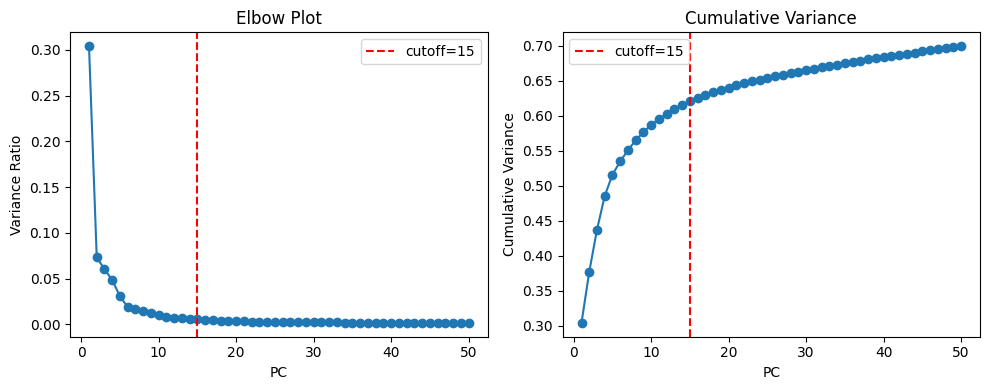

In [20]:
import matplotlib.pyplot as plt

variance_ratio = adata_filt.uns['pca']['variance_ratio']
cumulative_var = np.cumsum(variance_ratio)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].plot(range(1, 51), variance_ratio, 'o-')
axes[0].axvline(x=15, color='red', linestyle='--', label='cutoff=15')
axes[0].set_xlabel('PC')
axes[0].set_ylabel('Variance Ratio')
axes[0].set_title('Elbow Plot')
axes[0].legend()

axes[1].plot(range(1, 51), cumulative_var, 'o-')
axes[1].axvline(x=15, color='red', linestyle='--', label='cutoff=15')
axes[1].set_xlabel('PC')
axes[1].set_ylabel('Cumulative Variance')
axes[1].set_title('Cumulative Variance')
axes[1].legend()

plt.tight_layout()
plt.show()

In [21]:
# Truncate to 15 PCs and run Harmony
adata_filt.obsm['X_pca'] = adata_filt.obsm['X_pca'][:, :15]

from scrna_benchmark.embedding import compute_harmony
compute_harmony(adata_filt, batch_col="donor_id", basis="X_pca", key_added="X_harmony", n_comps=15)

print(f"X_pca:     {adata_filt.obsm['X_pca'].shape}")
print(f"X_harmony: {adata_filt.obsm['X_harmony'].shape}")

2026-05-31 14:02:38,441 - harmonypy - INFO - Running Harmony (PyTorch on cpu)
2026-05-31 14:02:38,442 - harmonypy - INFO -   Parameters:
2026-05-31 14:02:38,442 - harmonypy - INFO -     max_iter_harmony: 10
2026-05-31 14:02:38,443 - harmonypy - INFO -     max_iter_kmeans: 20
2026-05-31 14:02:38,443 - harmonypy - INFO -     epsilon_cluster: 1e-05
2026-05-31 14:02:38,444 - harmonypy - INFO -     epsilon_harmony: 0.0001
2026-05-31 14:02:38,444 - harmonypy - INFO -     nclust: 100
2026-05-31 14:02:38,445 - harmonypy - INFO -     block_size: 0.05
2026-05-31 14:02:38,445 - harmonypy - INFO -     lamb: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
2026-05-31 14:02:38,446 - harmonypy - INFO -     theta: [2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2.]
2026-05-31 14:02:38,447 - harmonypy - INFO -     sigma: [0.1 0.1 0.1 0.1 0.1]...
2026-05-31 14:02:38,447 - harmonypy - INFO -     verbose: True
2026-05-31 14:02:38,448 - harmonypy - INFO -     random_state: 0
2026-05-31 14:

2026-05-31 14:02:38,565 - harmonypy - INFO - KMeans initialization complete.
2026-05-31 14:02:38,575 - harmonypy - INFO - Iteration 1 of 10
2026-05-31 14:02:39,054 - harmonypy - INFO - Iteration 2 of 10
2026-05-31 14:02:39,531 - harmonypy - INFO - Iteration 3 of 10
2026-05-31 14:02:39,893 - harmonypy - INFO - Iteration 4 of 10
2026-05-31 14:02:40,275 - harmonypy - INFO - Iteration 5 of 10
2026-05-31 14:02:40,524 - harmonypy - INFO - Iteration 6 of 10
2026-05-31 14:02:40,737 - harmonypy - INFO - Iteration 7 of 10
2026-05-31 14:02:41,006 - harmonypy - INFO - Iteration 8 of 10
2026-05-31 14:02:41,274 - harmonypy - INFO - Iteration 9 of 10
2026-05-31 14:02:41,657 - harmonypy - INFO - Iteration 10 of 10
2026-05-31 14:02:42,062 - harmonypy - INFO - Stopped before convergence


X_pca:     (8746, 15)
X_harmony: (8746, 15)


In [22]:
# scVI — train on HVG raw counts
import scvi, scipy.sparse as sp

# Subset raw counts to HVG genes and add as layer
adata_filt.layers["counts"] = counts_raw[:, hvg_mask]

scvi.settings.seed = 42
scvi.model.SCVI.setup_anndata(adata_filt, layer="counts", batch_key="donor_id")
model = scvi.model.SCVI(adata_filt, n_latent=15)
model.train(max_epochs=200, early_stopping=True)
adata_filt.obsm["X_scVI"] = model.get_latent_representation()
print(f"X_scVI: {adata_filt.obsm['X_scVI'].shape}")

[rank: 0] Seed set to 42


/users/xchen5/.local/lib/python3.9/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python3 /users/xchen5/.local/lib/python3.9/site-packages/ip ...
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
/users/xchen5/.local/lib/python3.9/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python3 /users/xchen5/.local/lib/python3.9/site-packages/ip ...


Epoch 200/200: 100%|█████████████████████████████████████████| 200/200 [03:07<00:00,  1.09it/s, v_num=1, train_loss_step=449, train_loss_epoch=425]

`Trainer.fit` stopped: `max_epochs=200` reached.


Epoch 200/200: 100%|█████████████████████████████████████████| 200/200 [03:07<00:00,  1.07it/s, v_num=1, train_loss_step=449, train_loss_epoch=425]
X_scVI: (8746, 15)


In [23]:
# Final verification
print("=== Benchmark-Ready Object ===")
print(adata_filt)
print(f"\n  X_pca:     {adata_filt.obsm['X_pca'].shape}")
print(f"  X_harmony: {adata_filt.obsm['X_harmony'].shape}")
print(f"  X_scVI:    {adata_filt.obsm['X_scVI'].shape}")
print(f"\n  cell_type: {adata_filt.obs['cell_type'].nunique()} types")
print(f"  donor_id:  {adata_filt.obs['donor_id'].nunique()} donors")
print(f"  cells:     {adata_filt.n_obs:,}")

=== Benchmark-Ready Object ===
AnnData object with n_obs × n_vars = 8746 × 1000
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'sampletype', 'CMVstatus', 'percent.mt', 'Group', 'Female', 'Male', 'sampleType', 'log10GenesPerUMI', 'nCount_SCT', 'nFeature_SCT', 'SCT_snn_res.0.8', 'seurat_clusters', 'S.Score', 'G2M.Score', 'Phase', 'percent.ribo', 'study_pi', 'sample_id', 'donor_id', 'protocol_url', 'institute', 'library_id', 'library_id_repository', 'manner_of_death', 'sample_source', 'sex_ontology_term_id', 'sample_collection_method', 'tissue_type', 'sampled_site_condition', 'tissue_ontology_term_id', 'tissue_free_text', 'sample_preservation_method', 'suspension_type', 'cell_enrichment', 'assay_ontology_term_id', 'sequenced_fragment', 'sequencing_platform', 'is_primary_data', 'reference_genome', 'alignment_software', 'intron_inclusion', 'disease_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'development_stage_ontology_term_id', 'library_preparation_batch', 'library

In [25]:
out_path = Path("data/kidney/kidney_benchmark_ready.h5ad")
out_path.parent.mkdir(parents=True, exist_ok=True)
adata_filt.write(out_path)
print(f"Saved: {out_path}  ({out_path.stat().st_size/1e6:.1f} MB)")

Saved: data/kidney/kidney_benchmark_ready.h5ad  (180.3 MB)
